# SentencePiece / SubwordTextEncoder 한국어 토크나이저

## 왜 Subword Tokenization인가?

```
단어 단위 토큰화의 문제:
  '공부한다', '공부했다', '공부할' → 모두 다른 단어로 처리 → OOV 폭증

Subword 토큰화:
  '공부한다' → ['공부', '##한다']
  '공부했다' → ['공부', '##했다']
  '공부할'   → ['공부', '##할']
  → '공부' 공유 → 어휘 크기 감소 + OOV 해결!
```

## 세 가지 방법 비교

| 방법 | 알고리즘 | 특징 | 언어 |
|------|----------|------|------|
| **BPE** | 빈도 기반 병합 | 빠름, 결정적 | 영어 강점 |
| **SentencePiece** | BPE/Unigram LM | 언어 무관, 공백 처리 | 다국어 |
| **WordPiece** | 최대 우도 기반 | BERT 사용 방식 | 다국어 |
| **MeCab** | 형태소 분석 | 한국어 문법 기반 | 한국어 특화 |

In [5]:
# ── 한글 폰트 설치 ──────────────────────────────────────────
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 필요 라이브러리 설치 ──────────────────────────────────────
!pip install sentencepiece tokenizers konlpy --quiet

import sentencepiece as spm
import re, os, json, collections
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ 설치 완료')

✅ 설치 완료


## 1️⃣ 한국어 코퍼스 준비

In [6]:
# 한국어 샘플 코퍼스 (뉴스/일상 문체 혼합)
KOREAN_CORPUS = [
    "인공지능 기술이 빠르게 발전하고 있습니다.",
    "자연어 처리는 컴퓨터가 인간의 언어를 이해하는 기술입니다.",
    "딥러닝 모델은 대량의 데이터로 학습합니다.",
    "한국어는 교착어로 어미 변화가 풍부합니다.",
    "서울에서 부산까지 기차로 세 시간이 걸립니다.",
    "오늘 날씨가 맑아서 산책하기 좋은 날입니다.",
    "공부를 열심히 하면 좋은 결과를 얻을 수 있습니다.",
    "삼성전자는 세계적인 반도체 기업입니다.",
    "한국의 음식 문화는 세계적으로 인기가 높습니다.",
    "영화와 드라마를 통해 한국 문화가 전파되고 있습니다.",
    "기계 번역 시스템의 성능이 크게 향상되었습니다.",
    "언어 모델은 다음 단어를 예측하는 방식으로 학습합니다.",
    "형태소 분석은 한국어 처리의 핵심 단계입니다.",
    "서브워드 토크나이저는 미등록 단어 문제를 해결합니다.",
    "트랜스포머 아키텍처는 자연어 처리 분야를 혁신했습니다.",
    "데이터 증강 기법은 모델 성능 향상에 도움이 됩니다.",
    "사전 학습 모델을 파인튜닝하면 좋은 성능을 낼 수 있습니다.",
    "한국어 토크나이저는 다양한 방식으로 구현됩니다.",
    "어절 단위와 형태소 단위 토큰화의 차이를 이해해야 합니다.",
    "바이트 페어 인코딩은 반복적인 문자 쌍 병합으로 작동합니다.",
    "언어학적 지식을 활용하면 더 정확한 분석이 가능합니다.",
    "감성 분석은 텍스트의 긍정과 부정을 판별하는 작업입니다.",
    "개체명 인식은 텍스트에서 고유명사를 추출합니다.",
    "질문 응답 시스템은 자연어 질문에 자동으로 답변합니다.",
    "기계 번역의 품질은 BLEU 점수로 측정합니다.",
]

# 코퍼스 파일 저장
corpus_path = '/tmp/korean_corpus.txt'
with open(corpus_path, 'w', encoding='utf-8') as f:
    for line in KOREAN_CORPUS:
        f.write(line + '\n')

print(f'코퍼스: {len(KOREAN_CORPUS)}개 문장')
print(f'전체 글자 수: {sum(len(s) for s in KOREAN_CORPUS):,}')
print(f'\n예시 문장:')
for s in KOREAN_CORPUS[:3]:
    print(f'  {s}')

코퍼스: 25개 문장
전체 글자 수: 690

예시 문장:
  인공지능 기술이 빠르게 발전하고 있습니다.
  자연어 처리는 컴퓨터가 인간의 언어를 이해하는 기술입니다.
  딥러닝 모델은 대량의 데이터로 학습합니다.


## 2️⃣ SentencePiece 구현

```
SentencePiece 특징:
  ① 언어 비의존적: 공백을 특수 기호(▁)로 처리
  ② 두 가지 알고리즘:
     - BPE  : 빈도 기반 문자 쌍 반복 병합
     - Unigram: 확률 모델 기반 최적 분할
  ③ 입력: 원시 텍스트 (공백/특수문자 포함)
  ④ 완전히 가역적: 원본 텍스트 복원 가능
```

In [7]:
# ── SentencePiece BPE 학습 ──────────────────────────────────
spm.SentencePieceTrainer.train(
    input        = corpus_path,
    model_prefix = '/tmp/spm_bpe',
    vocab_size   = 226,
    model_type   = 'bpe',           # 'bpe' | 'unigram' | 'char' | 'word'
    character_coverage = 0.9995,    # 한국어는 0.9995 권장
    pad_id  = 0,  unk_id = 1,
    bos_id  = 2,  eos_id = 3,
    user_defined_symbols = ['<sep>', '<cls>', '<mask>'],
)

# ── SentencePiece Unigram 학습 ──────────────────────────────
spm.SentencePieceTrainer.train(
    input        = corpus_path,
    model_prefix = '/tmp/spm_unigram',
    vocab_size   = 226,
    model_type   = 'unigram',
    character_coverage = 0.9995,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

# 모델 로드
sp_bpe     = spm.SentencePieceProcessor()
sp_unigram = spm.SentencePieceProcessor()
sp_bpe.load('/tmp/spm_bpe.model')
sp_unigram.load('/tmp/spm_unigram.model')

print('✅ SentencePiece 학습 완료')
print(f'  BPE 어휘 크기:     {sp_bpe.get_piece_size()}')
print(f'  Unigram 어휘 크기: {sp_unigram.get_piece_size()}')

✅ SentencePiece 학습 완료
  BPE 어휘 크기:     226
  Unigram 어휘 크기: 226


In [8]:
# ── SentencePiece 토크나이저 상세 분석 ───────────────────────
test_sentences = [
    "인공지능이 세상을 바꾸고 있습니다.",
    "자연어처리를 공부합니다.",
    "형태소분석기를 활용합니다.",
    "미등록단어테스트해봅니다.",   # OOV 테스트
]

print('='*70)
print(f'  SentencePiece 토크나이징 결과')
print('='*70)

for sent in test_sentences:
    bpe_pieces    = sp_bpe.encode(sent, out_type=str)
    bpe_ids       = sp_bpe.encode(sent)
    uni_pieces    = sp_unigram.encode(sent, out_type=str)

    print(f'\n원문:    {sent}')
    print(f'BPE:     {bpe_pieces}')
    print(f'Unigram: {uni_pieces}')
    print(f'ID 시퀀스 (BPE): {bpe_ids[:8]}...' if len(bpe_ids)>8 else f'ID 시퀀스: {bpe_ids}')

    # 역변환 (원본 복원)
    decoded = sp_bpe.decode(bpe_ids)
    print(f'복원:    {decoded}  ← 원본과 동일: {decoded == sent}')

print('\n▁ 기호: 단어 시작(공백) 위치를 나타냄 → 완전히 가역적')

  SentencePiece 토크나이징 결과

원문:    인공지능이 세상을 바꾸고 있습니다.
BPE:     ['▁인', '공', '지', '능', '이', '▁세', '상', '을', '▁', '바', '꾸', '고', '▁있습니다', '.']
Unigram: ['▁인', '공', '지', '능', '이', '▁세', '상', '을', '▁', '바', '꾸', '고', '▁', '있', '습', '니', '다', '.']
ID 시퀀스 (BPE): [12, 103, 94, 61, 44, 25, 123, 68]...
복원:    인공지능이 세상을 바 ⁇ 고 있습니다.  ← 원본과 동일: False

원문:    자연어처리를 공부합니다.
BPE:     ['▁자', '연어', '처', '리', '를', '▁', '공', '부', '합니다', '.']
Unigram: ['▁자', '연', '어', '처', '리', '를', '▁', '공', '부', '합', '니', '다', '.']
ID 시퀀스 (BPE): [21, 32, 81, 85, 51, 39, 103, 74]...
복원:    자연어처리를 공부합니다.  ← 원본과 동일: True

원문:    형태소분석기를 활용합니다.
BPE:     ['▁', '형', '태', '소', '분', '석', '기', '를', '▁', '활', '용', '합니다', '.']
Unigram: ['▁', '형', '태', '소', '분', '석', '기', '를', '▁', '활', '용', '합', '니', '다', '.']
ID 시퀀스 (BPE): [39, 143, 139, 124, 75, 87, 49, 51]...
복원:    형태소분석기를 활용합니다.  ← 원본과 동일: True

원문:    미등록단어테스트해봅니다.
BPE:     ['▁', '미', '등', '록', '단', '어', '테', '스', '트', '해', '봅', '니다', '.']
Unigram: ['▁', '미', '등', '록', '단', '어

## 3️⃣ SubwordTextEncoder (Tensor2Tensor 방식) 직접 구현

```
SubwordTextEncoder 알고리즘:
  1. 문자 빈도로 초기 어휘 구성
  2. 자주 등장하는 문자열을 어휘에 추가 (Bottom-up)
  3. 목표 어휘 크기에 도달할 때까지 반복
  
  차이점 vs SentencePiece BPE:
  - 공백을 '_' 로 처리 (단어 끝 표시)
  - 최소 빈도 임계값으로 어휘 제어
```

In [9]:
class SubwordTextEncoder:
    """
    Tensor2Tensor SubwordTextEncoder 재구현

    Sennrich et al. (2016) BPE 기반
    한국어/영어 모두 사용 가능
    """

    WORD_END = '_'   # 단어 끝 마커

    def __init__(self):
        self.vocab      = {}    # subword → id
        self.rev_vocab  = {}    # id → subword
        self.special_tokens = ['<pad>','<unk>','<bos>','<eos>']

    # ── 어휘 구축 ─────────────────────────────────────────────
    def build_from_corpus(self, sentences, target_vocab_size=300, min_count=2):
        """
        Step 1: 문자 단위 빈도 수집
        Step 2: 빈도 높은 서브워드를 어휘에 추가
        Step 3: target_vocab_size 도달 시 종료
        """
        print(f'SubwordTextEncoder 구축 시작 (목표 어휘: {target_vocab_size})')

        # 단어 빈도 수집 (단어 끝에 _ 추가)
        word_freq = Counter()
        for sent in sentences:
            for word in sent.replace(' ', ' ').split():
                word_freq[word + self.WORD_END] += 1

        # 단어를 문자 단위로 분리
        splits = {word: list(word) for word in word_freq}

        # 초기 문자 어휘
        char_vocab = set()
        for word in splits:
            char_vocab.update(splits[word])

        print(f'  초기 문자 어휘: {len(char_vocab)}개')

        # BPE 병합 반복
        merges = []
        current_vocab = set(char_vocab)

        while len(current_vocab) + len(self.special_tokens) < target_vocab_size:
            # 인접 쌍 빈도 계산
            pair_freq = Counter()
            for word, freq in word_freq.items():
                tokens = splits[word]
                for i in range(len(tokens)-1):
                    pair_freq[(tokens[i], tokens[i+1])] += freq

            if not pair_freq:
                break

            # 가장 빈도 높은 쌍 병합
            best_pair = max(pair_freq, key=pair_freq.get)
            best_freq = pair_freq[best_pair]

            if best_freq < min_count:
                break

            # 병합 실행
            new_token = best_pair[0] + best_pair[1]
            merges.append((best_pair, new_token, best_freq))
            current_vocab.add(new_token)

            # 모든 단어에 병합 적용
            for word in splits:
                tokens = splits[word]
                new_tokens = []
                i = 0
                while i < len(tokens):
                    if (i < len(tokens)-1 and
                        tokens[i] == best_pair[0] and
                        tokens[i+1] == best_pair[1]):
                        new_tokens.append(new_token)
                        i += 2
                    else:
                        new_tokens.append(tokens[i])
                        i += 1
                splits[word] = new_tokens

        self.merges     = merges
        self.word_splits= splits

        # 어휘 사전 구축
        all_tokens = self.special_tokens + sorted(current_vocab)
        self.vocab     = {t: i for i, t in enumerate(all_tokens)}
        self.rev_vocab = {i: t for t, i in self.vocab.items()}

        print(f'  병합 횟수:  {len(merges)}회')
        print(f'  최종 어휘:  {len(self.vocab)}개')
        return merges

    # ── 인코딩 ───────────────────────────────────────────────
    def encode(self, text):
        tokens = []
        for word in text.split():
            word_with_end = word + self.WORD_END
            # 학습된 병합 순서대로 적용
            chars = list(word_with_end)
            for (a, b), merged, _ in self.merges:
                new_chars = []
                i = 0
                while i < len(chars):
                    if i < len(chars)-1 and chars[i]==a and chars[i+1]==b:
                        new_chars.append(merged)
                        i += 2
                    else:
                        new_chars.append(chars[i])
                        i += 1
                chars = new_chars
            tokens.extend(chars)

        unk_id = self.vocab.get('<unk>', 1)
        return [self.vocab.get(t, unk_id) for t in tokens]

    def decode(self, ids):
        tokens = [self.rev_vocab.get(i, '<unk>') for i in ids
                  if i not in (self.vocab.get('<pad>',0),
                               self.vocab.get('<bos>',2),
                               self.vocab.get('<eos>',3))]
        text = ''.join(tokens).replace(self.WORD_END, ' ').strip()
        return text

    def tokenize(self, text):
        ids = self.encode(text)
        return [self.rev_vocab.get(i, '<unk>') for i in ids]


# 학습 실행
ste = SubwordTextEncoder()
merges = ste.build_from_corpus(KOREAN_CORPUS, target_vocab_size=300, min_count=2)

SubwordTextEncoder 구축 시작 (목표 어휘: 300)
  초기 문자 어휘: 187개
  병합 횟수:  72회
  최종 어휘:  263개


In [10]:
# SubwordTextEncoder 결과 확인
print('[SubwordTextEncoder 토크나이징 테스트]\n')

for sent in test_sentences:
    tokens  = ste.tokenize(sent)
    ids     = ste.encode(sent)
    decoded = ste.decode(ids)
    print(f'원문:   {sent}')
    print(f'토큰:   {tokens}')
    print(f'복원:   {decoded}')
    print()

print(f'[상위 20개 병합 규칙]')
print(f'{"순위":>4} | {"병합 쌍":>20} | {"결과":>12} | 빈도')
print('-' * 50)
for i, ((a, b), merged, freq) in enumerate(merges[:20], 1):
    print(f'{i:>4} | {a!r:>10} + {b!r:<10}| {merged!r:>12} | {freq}')

[SubwordTextEncoder 토크나이징 테스트]

원문:   인공지능이 세상을 바꾸고 있습니다.
토큰:   ['인', '공', '지', '능', '이_', '세', '상', '을_', '바', '<unk>', '고_', '있습니다._']
복원:   인공지능이 세상을 바<unk>고 있습니다.

원문:   자연어처리를 공부합니다.
토큰:   ['자연', '어', '처리', '를_', '공', '부', '합니다._']
복원:   자연어처리를 공부합니다.

원문:   형태소분석기를 활용합니다.
토큰:   ['형태소', '분석', '기', '를_', '활', '용', '합니다._']
복원:   형태소분석기를 활용합니다.

원문:   미등록단어테스트해봅니다.
토큰:   ['미', '등', '록', '단', '어', '<unk>', '스', '트', '해', '<unk>', '니다._']
복원:   미등록단어<unk>스트해<unk>니다.

[상위 20개 병합 규칙]
  순위 |                 병합 쌍 |           결과 | 빈도
--------------------------------------------------
   1 |        '니' + '다'       |         '니다' | 25
   2 |       '니다' + '.'       |        '니다.' | 25
   3 |      '니다.' + '_'       |       '니다._' | 25
   4 |        '은' + '_'       |         '은_' | 12
   5 |        '는' + '_'       |         '는_' | 10
   6 |        '합' + '니다._'    |      '합니다._' | 10
   7 |        '를' + '_'       |         '를_' | 9
   8 |        '로' + '_'       |         '로_' | 9
   9 |        '

## 4️⃣ MeCab 형태소 분석기

In [11]:
# MeCab 설치 (Google Colab 전용)
import subprocess
result = subprocess.run(
    ['pip', 'install', 'python-mecab-ko', '--quiet'],
    capture_output=True, text=True
)
print('MeCab 설치 시도...')

try:
    from mecab import MeCab
    mecab = MeCab()
    MECAB_AVAILABLE = True
    print('✅ MeCab 사용 가능')
except ImportError:
    try:
        !pip install python-mecab-ko -q
        from mecab import MeCab
        mecab = MeCab()
        MECAB_AVAILABLE = True
        print('✅ MeCab 설치 및 로드 완료')
    except:
        MECAB_AVAILABLE = False
        print('⚠️  MeCab 설치 실패 → KoNLPy Okt로 대체')

# KoNLPy 백업
try:
    from konlpy.tag import Okt, Kkma
    okt = Okt()
    KONLPY_AVAILABLE = True
    print('✅ KoNLPy(Okt) 사용 가능')
except:
    KONLPY_AVAILABLE = False
    print('⚠️  KoNLPy 사용 불가')

MeCab 설치 시도...
✅ MeCab 사용 가능
✅ KoNLPy(Okt) 사용 가능


In [12]:
# 형태소 분석 비교
morph_test = [
    "나는 학교에 갑니다.",
    "인공지능 기술이 발전하고 있습니다.",
    "오늘 날씨가 맑아서 기분이 좋습니다.",
]

print('[형태소 분석 결과 비교]\n')

for sent in morph_test:
    print(f'원문: {sent}')

    # MeCab
    if MECAB_AVAILABLE:
        try:
            result = mecab.pos(sent)
            print(f'MeCab: {result}')
        except:
            print(f'MeCab: 분석 실패')

    # KoNLPy Okt
    if KONLPY_AVAILABLE:
        morphs = okt.morphs(sent)
        pos    = okt.pos(sent)
        nouns  = okt.nouns(sent)
        print(f'Okt 형태소: {morphs}')
        print(f'Okt 품사:   {pos}')
        print(f'Okt 명사:   {nouns}')

    # SentencePiece
    sp_result = sp_bpe.encode(sent, out_type=str)
    print(f'SentencePiece(BPE): {sp_result}')
    print()

[형태소 분석 결과 비교]

원문: 나는 학교에 갑니다.
MeCab: [('나', 'NP'), ('는', 'JX'), ('학교', 'NNG'), ('에', 'JKB'), ('갑니다', 'VV+EF'), ('.', 'SF')]
Okt 형태소: ['나', '는', '학교', '에', '갑니다', '.']
Okt 품사:   [('나', 'Noun'), ('는', 'Josa'), ('학교', 'Noun'), ('에', 'Josa'), ('갑니다', 'Verb'), ('.', 'Punctuation')]
Okt 명사:   ['나', '학교']
SentencePiece(BPE): ['▁', '나', '는', '▁학', '교', '에', '▁', '갑', '니다', '.']

원문: 인공지능 기술이 발전하고 있습니다.
MeCab: [('인공지능', 'NNP'), ('기술', 'NNG'), ('이', 'JKS'), ('발전', 'NNG'), ('하', 'XSV'), ('고', 'EC'), ('있', 'VX'), ('습니다', 'EF'), ('.', 'SF')]
Okt 형태소: ['인공', '지능', '기술', '이', '발전', '하고', '있습니다', '.']
Okt 품사:   [('인공', 'Noun'), ('지능', 'Noun'), ('기술', 'Noun'), ('이', 'Josa'), ('발전', 'Noun'), ('하고', 'Josa'), ('있습니다', 'Adjective'), ('.', 'Punctuation')]
Okt 명사:   ['인공', '지능', '기술', '발전']
SentencePiece(BPE): ['▁인', '공', '지', '능', '▁기', '술', '이', '▁', '발', '전', '하', '고', '▁있습니다', '.']

원문: 오늘 날씨가 맑아서 기분이 좋습니다.
MeCab: [('오늘', 'MAG'), ('날씨', 'NNG'), ('가', 'JKS'), ('맑', 'VA'), ('아서', 'EC'), ('기분', 'NNG'), ('

## 5️⃣ 세 가지 토크나이저 종합 비교 시각화

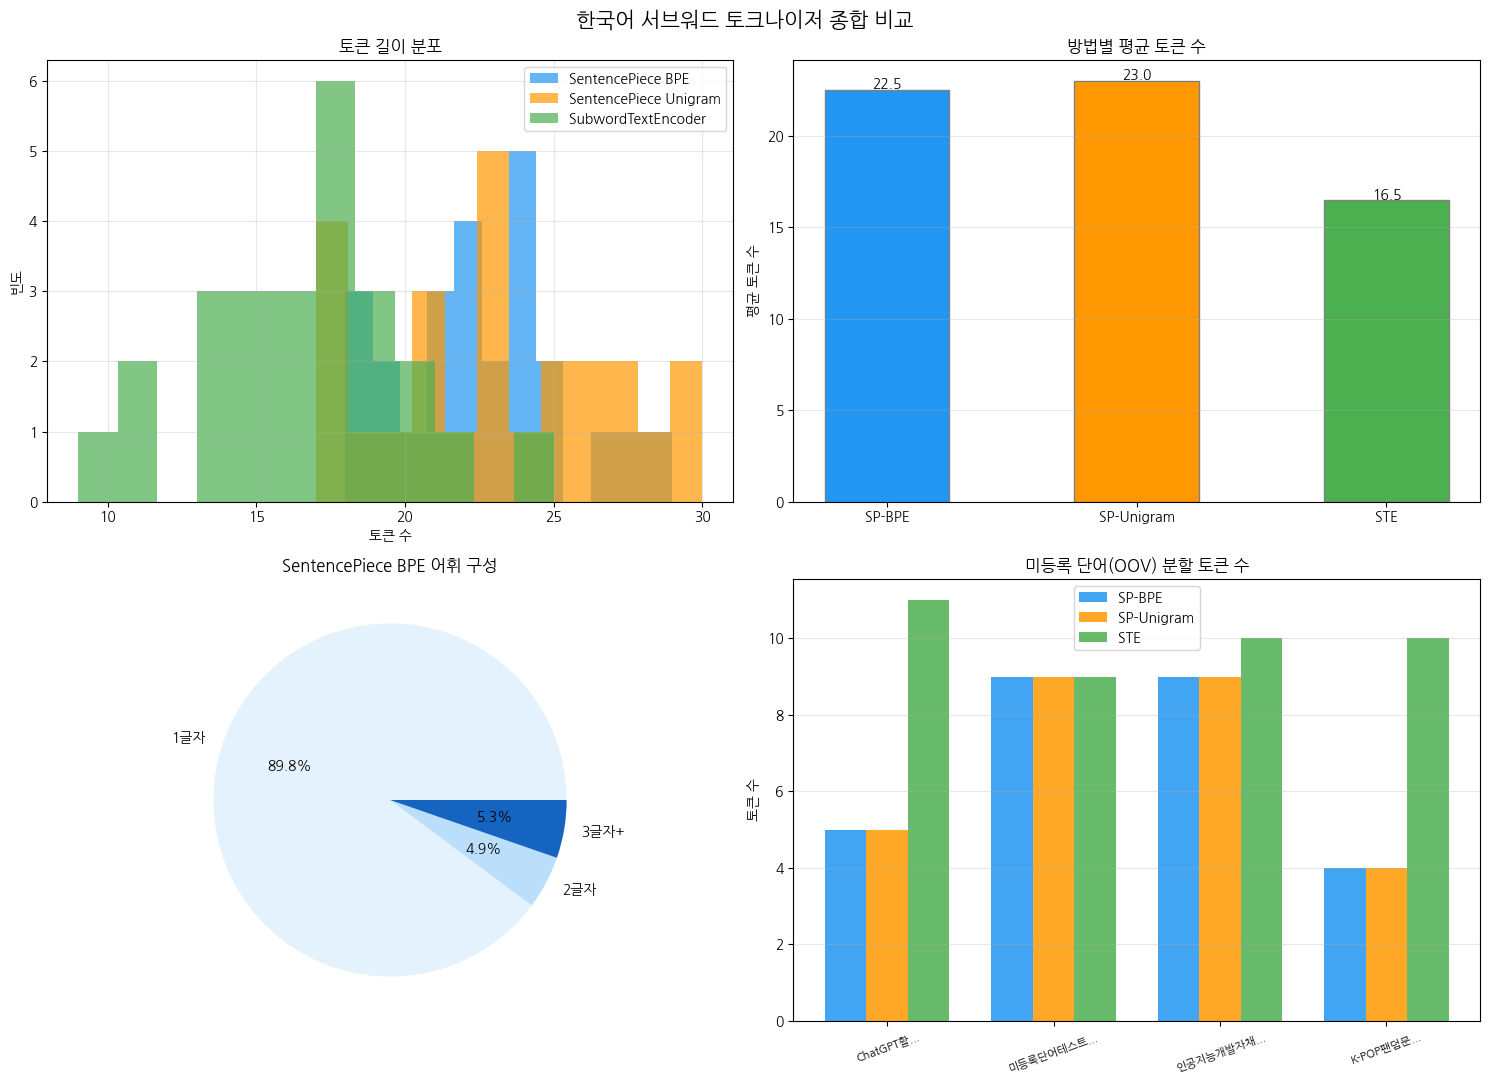

In [13]:
# 토큰 길이 분포 비교
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sp_bpe_lens, sp_uni_lens, ste_lens = [], [], []
for sent in KOREAN_CORPUS:
    sp_bpe_lens.append(len(sp_bpe.encode(sent)))
    sp_uni_lens.append(len(sp_unigram.encode(sent)))
    ste_lens.append(len(ste.encode(sent)))

# 분포 히스토그램
ax = axes[0, 0]
ax.hist(sp_bpe_lens, bins=12, alpha=0.7, label='SentencePiece BPE',    color='#2196F3')
ax.hist(sp_uni_lens, bins=12, alpha=0.7, label='SentencePiece Unigram', color='#FF9800')
ax.hist(ste_lens,    bins=12, alpha=0.7, label='SubwordTextEncoder',    color='#4CAF50')
ax.set_title('토큰 길이 분포', fontweight='bold')
ax.set_xlabel('토큰 수'); ax.set_ylabel('빈도')
ax.legend(); ax.grid(alpha=0.3)

# 평균 토큰 길이 비교
ax = axes[0, 1]
methods = ['SP-BPE', 'SP-Unigram', 'STE']
means   = [np.mean(sp_bpe_lens), np.mean(sp_uni_lens), np.mean(ste_lens)]
colors  = ['#2196F3','#FF9800','#4CAF50']
bars = ax.bar(methods, means, color=colors, edgecolor='gray', width=0.5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{m:.1f}', ha='center', fontweight='bold')
ax.set_title('방법별 평균 토큰 수', fontweight='bold')
ax.set_ylabel('평균 토큰 수'); ax.grid(axis='y', alpha=0.3)

# SentencePiece 어휘 구성 비율
ax = axes[1, 0]
vocab_items = [(sp_bpe.id_to_piece(i), sp_bpe.get_score(i))
               for i in range(sp_bpe.get_piece_size())]
single_char = sum(1 for p, _ in vocab_items if len(p.replace('▁',''))==1)
two_char    = sum(1 for p, _ in vocab_items if len(p.replace('▁',''))==2)
multi_char  = len(vocab_items) - single_char - two_char
ax.pie([single_char, two_char, multi_char],
       labels=['1글자','2글자','3글자+'],
       autopct='%1.1f%%',
       colors=['#E3F2FD','#BBDEFB','#1565C0'])
ax.set_title('SentencePiece BPE 어휘 구성', fontweight='bold')

# 토크나이저별 OOV 처리 비교
ax = axes[1, 1]
oov_words = ['ChatGPT활용법', '미등록단어테스트', '인공지능개발자채용', 'K-POP팬덤문화']
sp_bpe_oov    = [len([t for t in sp_bpe.encode(w, out_type=str) if '▁' not in t or len(t)<=2])
                  for w in oov_words]
sp_uni_oov    = [len(sp_unigram.encode(w, out_type=str)) for w in oov_words]
ste_oov       = [len(ste.tokenize(w)) for w in oov_words]

x = np.arange(len(oov_words))
w = 0.25
ax.bar(x-w,   sp_bpe_oov, w, label='SP-BPE',    color='#2196F3', alpha=0.85)
ax.bar(x,     sp_uni_oov, w, label='SP-Unigram', color='#FF9800', alpha=0.85)
ax.bar(x+w,   ste_oov,    w, label='STE',        color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([w[:8]+'...' for w in oov_words], rotation=20, fontsize=8)
ax.set_title('미등록 단어(OOV) 분할 토큰 수', fontweight='bold')
ax.set_ylabel('토큰 수'); ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.suptitle('한국어 서브워드 토크나이저 종합 비교', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('tokenizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ HuggingFace tokenizers 라이브러리 활용

In [14]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# HuggingFace BPE 토크나이저 학습
hf_tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
hf_tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size        = 500,
    min_frequency     = 1,
    special_tokens    = ['[PAD]','[UNK]','[CLS]','[SEP]','[MASK]'],
    show_progress     = False,
)
hf_tokenizer.train([corpus_path], trainer)
hf_tokenizer.save('/tmp/hf_bpe.json')

# 결과 비교
print('[HuggingFace BPE vs SentencePiece 비교]\n')
print(f'HuggingFace 어휘 크기: {hf_tokenizer.get_vocab_size()}')

for sent in test_sentences[:3]:
    hf_enc  = hf_tokenizer.encode(sent)
    sp_enc  = sp_bpe.encode(sent, out_type=str)
    print(f'\n문장: {sent}')
    print(f'  HF BPE:        {hf_enc.tokens}')
    print(f'  SentencePiece: {sp_enc}')

[HuggingFace BPE vs SentencePiece 비교]

HuggingFace 어휘 크기: 450

문장: 인공지능이 세상을 바꾸고 있습니다.
  HF BPE:        ['인공지능', '이', '세', '상', '을', '바', '[UNK]', '고', '있습니다', '.']
  SentencePiece: ['▁인', '공', '지', '능', '이', '▁세', '상', '을', '▁', '바', '꾸', '고', '▁있습니다', '.']

문장: 자연어처리를 공부합니다.
  HF BPE:        ['자연어', '처리', '를', '공부', '합니다', '.']
  SentencePiece: ['▁자', '연어', '처', '리', '를', '▁', '공', '부', '합니다', '.']

문장: 형태소분석기를 활용합니다.
  HF BPE:        ['형태소', '분석', '기', '를', '활', '용', '합니다', '.']
  SentencePiece: ['▁', '형', '태', '소', '분', '석', '기', '를', '▁', '활', '용', '합니다', '.']


## 7️⃣ 실전 파이프라인: 토크나이저 → 모델 입력

In [15]:
import torch
import torch.nn as nn

class KoreanNLPPipeline:
    """
    토크나이저 → 모델 입력 변환 파이프라인
    실제 NLP 모델 학습 전 전처리 단계
    """
    def __init__(self, tokenizer, max_len=64):
        self.sp  = tokenizer
        self.max_len = max_len
        self.pad_id  = tokenizer.piece_to_id('<pad>') if hasattr(tokenizer, 'piece_to_id') else 0
        self.bos_id  = tokenizer.piece_to_id('<bos>') if hasattr(tokenizer, 'piece_to_id') else 2
        self.eos_id  = tokenizer.piece_to_id('<eos>') if hasattr(tokenizer, 'piece_to_id') else 3

    def __call__(self, texts, return_tensors=True):
        batch_ids      = []
        batch_masks    = []
        batch_tokens   = []

        for text in texts:
            ids    = [self.bos_id] + self.sp.encode(text) + [self.eos_id]
            tokens = self.sp.encode(text, out_type=str)

            # 자르기 & 패딩
            if len(ids) > self.max_len:
                ids = ids[:self.max_len-1] + [self.eos_id]
            mask = [1] * len(ids)
            while len(ids) < self.max_len:
                ids.append(self.pad_id)
                mask.append(0)

            batch_ids.append(ids)
            batch_masks.append(mask)
            batch_tokens.append(tokens)

        result = {'tokens': batch_tokens,
                  'input_ids': batch_ids,
                  'attention_mask': batch_masks}

        if return_tensors:
            result['input_ids']       = torch.tensor(batch_ids)
            result['attention_mask']  = torch.tensor(batch_masks)

        return result


pipeline = KoreanNLPPipeline(sp_bpe, max_len=30)

batch = pipeline(test_sentences[:3])
print('[파이프라인 출력]\n')
for i, sent in enumerate(test_sentences[:3]):
    print(f'문장: {sent}')
    print(f'  tokens:    {batch["tokens"][i]}')
    print(f'  input_ids: {batch["input_ids"][i].tolist()}')
    print(f'  att_mask:  {batch["attention_mask"][i].tolist()}')
    print()

print(f'배치 텐서 shape: {batch["input_ids"].shape}')

[파이프라인 출력]

문장: 인공지능이 세상을 바꾸고 있습니다.
  tokens:    ['▁인', '공', '지', '능', '이', '▁세', '상', '을', '▁', '바', '꾸', '고', '▁있습니다', '.']
  input_ids: [1, 12, 103, 94, 61, 44, 25, 123, 68, 39, 174, 1, 84, 23, 41, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  att_mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

문장: 자연어처리를 공부합니다.
  tokens:    ['▁자', '연어', '처', '리', '를', '▁', '공', '부', '합니다', '.']
  input_ids: [1, 21, 32, 81, 85, 51, 39, 103, 74, 8, 41, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  att_mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

문장: 형태소분석기를 활용합니다.
  tokens:    ['▁', '형', '태', '소', '분', '석', '기', '를', '▁', '활', '용', '합니다', '.']
  input_ids: [1, 39, 143, 139, 124, 75, 87, 49, 51, 39, 224, 193, 8, 41, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  att_mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

배치 텐서 shape: torch

## 8️⃣ 토크나이저 방법별 정리

In [16]:
summary_data = {
    '방법': ['단어 단위', '형태소(MeCab/Okt)', 'SentencePiece BPE',
             'SentencePiece Unigram', 'SubwordTextEncoder', 'HuggingFace BPE'],
    'OOV 처리': ['❌ 불가', '△ 부분적', '✅ 완전', '✅ 완전', '✅ 완전', '✅ 완전'],
    '언어 독립': ['✅', '❌ 한국어 전용', '✅', '✅', '✅', '✅'],
    '속도':     ['⚡⚡⚡', '⚡', '⚡⚡', '⚡⚡', '⚡⚡', '⚡⚡'],
    '어휘 크기': ['대 (수십만)', '중', '소-중 (조절 가능)', '소-중', '소-중', '소-중'],
    '주요 사용처': ['초기 NLP', 'KoBERT, KLUE', 'XLM, mBART', 'XLNet(일부)', 'T2T', 'GPT, BERT 계열'],
}

df_summary = pd.DataFrame(summary_data)
print('[한국어 토크나이저 방법 비교표]\n')
print(df_summary.to_string(index=False))

print('''
💡 선택 가이드:
  ① 한국어 특화 + 형태소 정확도 최우선   → MeCab + SentencePiece 조합
  ② 다국어 모델 / 빠른 학습             → SentencePiece BPE (vocab=8000~32000)
  ③ 확률 기반 최적 분할 원할 때          → SentencePiece Unigram
  ④ HuggingFace 생태계 활용             → tokenizers 라이브러리 BPE/WordPiece
  ⑤ 교육/연구 목적 직접 구현             → SubwordTextEncoder (위 구현 참고)
''')

[한국어 토크나이저 방법 비교표]

                   방법 OOV 처리    언어 독립  속도       어휘 크기       주요 사용처
                단어 단위   ❌ 불가        ✅ ⚡⚡⚡     대 (수십만)       초기 NLP
       형태소(MeCab/Okt)  △ 부분적 ❌ 한국어 전용   ⚡           중 KoBERT, KLUE
    SentencePiece BPE   ✅ 완전        ✅  ⚡⚡ 소-중 (조절 가능)   XLM, mBART
SentencePiece Unigram   ✅ 완전        ✅  ⚡⚡         소-중    XLNet(일부)
   SubwordTextEncoder   ✅ 완전        ✅  ⚡⚡         소-중          T2T
      HuggingFace BPE   ✅ 완전        ✅  ⚡⚡         소-중 GPT, BERT 계열

💡 선택 가이드:
  ① 한국어 특화 + 형태소 정확도 최우선   → MeCab + SentencePiece 조합
  ② 다국어 모델 / 빠른 학습             → SentencePiece BPE (vocab=8000~32000)
  ③ 확률 기반 최적 분할 원할 때          → SentencePiece Unigram
  ④ HuggingFace 생태계 활용             → tokenizers 라이브러리 BPE/WordPiece
  ⑤ 교육/연구 목적 직접 구현             → SubwordTextEncoder (위 구현 참고)

